[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/firefly1248/demo-notebooks/blob/main/notebooks/catboost_rmsewithuncertainty_conformal.ipynb)

# CatBoost RMSEWithUncertainty: from a fitted sigma to a calibrated interval

`loss_function="RMSEWithUncertainty"` returns a mean and a variance per row. This notebook builds a
90% interval from it three ways and measures what each one costs.

1. Raw: `mu +- 1.645 sigma`, straight from the model.
2. Sigma-normalized conformal: widen by the empirical quantile of the normalized residuals on a
   held-out calibration set.
3. CQR: two quantile models, conformalize the gap (Romano, Patterson, Candes, *Conformalized
   Quantile Regression*, NeurIPS 2019).

One synthetic dataset and two public real ones. Reported: coverage, width, and where the misses
land relative to the interval.

The second half tests whether you can tell in advance that a symmetric interval will miss
lopsidedly. Skewness of the normalized residuals cannot. Two quantile measures can.

Runtime is about five minutes on a free Colab CPU.

In [1]:
try:
    import catboost
except ImportError:
    !pip install -q catboost

In [2]:
import numpy as np
import pandas as pd
from scipy.stats import skew, norm
from sklearn.model_selection import train_test_split
from catboost import CatBoostRegressor

ALPHA = 0.10          # target 90% coverage
SEED = 0
ITERS, LR, DEPTH = 1000, 0.05, 6

Z = norm.ppf(1 - ALPHA / 2)
print(f"target coverage {1 - ALPHA:.0%}, gaussian z = {Z:.4f}")

target coverage 90%, gaussian z = 1.6449


## Helpers

`conformal_q` applies the finite-sample correction from the CQR paper, eq. (8): the
`ceil((n+1)(1-alpha)) / n` empirical quantile of the calibration scores. The higher order statistic
is what makes coverage exact rather than asymptotic.

In [3]:
def conformal_q(scores, alpha=ALPHA):
    """Calibration-score quantile with the finite-sample correction."""
    n = len(scores)
    level = min(np.ceil((n + 1) * (1 - alpha)) / n, 1.0)
    return np.quantile(scores, level, method="higher")


def interval_stats(y, lo, hi):
    return {
        "coverage": float(np.mean((y >= lo) & (y <= hi)) * 100),
        "width": float(np.mean(hi - lo)),
        "missed_below": float(np.mean(y < lo) * 100),
        "missed_above": float(np.mean(y > hi) * 100),
    }


def asymmetry(r, alpha=ALPHA):
    q_lo, q_med, q_hi = np.quantile(r, [alpha / 2, 0.5, 1 - alpha / 2])
    return {
        "moment_skew": float(skew(r)),
        "bowley_skew": float((q_hi + q_lo - 2 * q_med) / (q_hi - q_lo)),
        "tail_ratio": float(abs(q_hi) / abs(q_lo)),
        "r_min": float(r.min()),
        "r_max": float(r.max()),
    }


def fit_quantile(Xtr, ytr, alpha_q, cat_features, seed=SEED):
    m = CatBoostRegressor(loss_function=f"Quantile:alpha={alpha_q}", iterations=ITERS,
                          learning_rate=LR, depth=DEPTH, random_seed=seed, verbose=0)
    m.fit(Xtr, ytr, cat_features=cat_features)
    return m


def fit_uncertainty(Xtr, ytr, cat_features, seed=SEED):
    m = CatBoostRegressor(loss_function="RMSEWithUncertainty", iterations=ITERS,
                          learning_rate=LR, depth=DEPTH, random_seed=seed, verbose=0)
    m.fit(Xtr, ytr, cat_features=cat_features)
    return m


def split(X, y, seed=SEED):
    """60 / 20 / 20: train, calibration, test."""
    Xtr, Xtmp, ytr, ytmp = train_test_split(X, y, test_size=0.4, random_state=seed)
    Xcal, Xte, ycal, yte = train_test_split(Xtmp, ytmp, test_size=0.5, random_state=seed)
    return Xtr, ytr, Xcal, ycal, Xte, yte

## The experiment

Fit on train, calibrate on calibration, measure on test.

CQR runs at two nominal quantile settings. The paper notes that cross-validating the nominal level
tends to pick quantiles narrower than the target, leaving more of the work to the conformal
correction. `5/95` matches the target level, `10/90` is the tuned alternative.

In [4]:
def run_dataset(name, X, y, cat_features, seed=SEED):
    Xtr, ytr, Xcal, ycal, Xte, yte = split(X, y, seed)

    unc = fit_uncertainty(Xtr, ytr, cat_features, seed)
    # column 0 is the mean, column 1 the variance
    pc, pt = unc.predict(Xcal), unc.predict(Xte)
    mu_cal, sd_cal = pc[:, 0], np.sqrt(pc[:, 1])
    mu_te, sd_te = pt[:, 0], np.sqrt(pt[:, 1])

    diag = {"n_train": len(ytr), "n_cal": len(ycal), "n_test": len(yte),
            "target_skew": float(skew(ytr)),
            "residual_skew": float(skew(ycal - mu_cal)),
            **asymmetry((ycal - mu_cal) / sd_cal)}

    rows = []

    # no calibration
    rows.append({"dataset": name, "method": "raw mu +- 1.645 sigma", "Q": np.nan, "base_width": np.nan,
                 **interval_stats(yte, mu_te - Z * sd_te, mu_te + Z * sd_te)})

    q_sig = conformal_q(np.abs(ycal - mu_cal) / sd_cal)
    rows.append({"dataset": name, "method": "sigma-normalized", "Q": float(q_sig), "base_width": np.nan,
                 **interval_stats(yte, mu_te - q_sig * sd_te, mu_te + q_sig * sd_te)})

    for lo_a, hi_a in [(0.05, 0.95), (0.10, 0.90)]:
        m_lo = fit_quantile(Xtr, ytr, lo_a, cat_features, seed)
        m_hi = fit_quantile(Xtr, ytr, hi_a, cat_features, seed)
        qlo_cal, qhi_cal = m_lo.predict(Xcal), m_hi.predict(Xcal)
        qlo_te, qhi_te = m_lo.predict(Xte), m_hi.predict(Xte)

        # CQR score, eq. (6)
        Q = conformal_q(np.maximum(qlo_cal - ycal, ycal - qhi_cal))
        rows.append({"dataset": name, "method": f"CQR {int(lo_a * 100)}/{int(hi_a * 100)}",
                     "Q": float(Q), "base_width": float(np.mean(qhi_te - qlo_te)),
                     **interval_stats(yte, qlo_te - Q, qhi_te + Q)})

    return pd.DataFrame(rows), diag

## Datasets

- Synthetic: right-skewed gamma noise with feature-dependent scale, so the conditional
  distribution is heteroscedastic and asymmetric by construction.
- Insurance charges, 1,338 rows.
- Diamonds price, 53,940 rows.

The two real targets are similarly right-skewed, 1.56 and 1.61. What separates them appears in
Result 3.

In [5]:
def make_synthetic(n=6000, seed=SEED):
    rng = np.random.default_rng(seed)
    X = pd.DataFrame(rng.uniform(0, 1, size=(n, 5)), columns=[f"x{i}" for i in range(5)])
    signal = 10 * np.sin(2 * np.pi * X["x0"]) + 5 * X["x1"]
    scale = 1 + 2 * X["x2"]
    noise = rng.gamma(shape=2.0, scale=scale) - 2 * scale     # zero-mean, right-skewed
    return X, (signal + noise).values, []


def load_insurance():
    url = "https://raw.githubusercontent.com/stedy/Machine-Learning-with-R-datasets/master/insurance.csv"
    df = pd.read_csv(url)
    return df.drop(columns=["charges"]), df["charges"].values, ["sex", "smoker", "region"]


def load_diamonds():
    url = "https://raw.githubusercontent.com/mwaskom/seaborn-data/master/diamonds.csv"
    df = pd.read_csv(url)
    return df.drop(columns=["price"]), df["price"].values, ["cut", "color", "clarity"]


LOADERS = {"Synthetic gamma noise": make_synthetic,
           "Insurance charges": load_insurance,
           "Diamonds price": load_diamonds}

In [6]:
results, diags = [], {}
for name, loader in LOADERS.items():
    X, y, cats = loader()
    res, diag = run_dataset(name, X, y, cats)
    results.append(res)
    diags[name] = diag
    print(f"{name:22s} n_cal={diag['n_cal']:6d}  done")

results = pd.concat(results, ignore_index=True)
diag_df = pd.DataFrame(diags).T

Synthetic gamma noise  n_cal=  1200  done


Insurance charges      n_cal=   268  done


Diamonds price         n_cal= 10788  done


## Result 1: the raw sigma is not an interval

`mu +- 1.645 sigma` looks like a 90% interval. Whether it is one depends on the dataset.

In [7]:
raw = results[results["method"] == "raw mu +- 1.645 sigma"].set_index("dataset")
print(raw[["coverage", "width", "missed_below", "missed_above"]].round(2).to_string())

                       coverage    width  missed_below  missed_above
dataset                                                             
Synthetic gamma noise     70.33     5.59         13.50         16.17
Insurance charges         73.88  4562.94         14.18         11.94
Diamonds price            89.22  1059.74          5.19          5.59


## Result 2: after conformal calibration

Each conformalized row carries a 90% guarantee that holds in expectation over the calibration
draw, so single splits land on either side of it (Result 5). What differs between methods is width
and where the misses land.

In [8]:
print(results.set_index(["dataset", "method"])[
    ["coverage", "width", "missed_below", "missed_above", "Q"]].round(2).to_string())

                                             coverage     width  missed_below  missed_above        Q
dataset               method                                                                        
Synthetic gamma noise raw mu +- 1.645 sigma     70.33      5.59         13.50         16.17      NaN
                      sigma-normalized          91.67     10.55          1.92          6.42     3.11
                      CQR 5/95                  91.08      9.13          2.58          6.33     1.00
                      CQR 10/90                 91.42      8.99          1.08          7.50     1.85
Insurance charges     raw mu +- 1.645 sigma     73.88   4562.94         14.18         11.94      NaN
                      sigma-normalized          91.79  13338.47          0.37          7.84     4.81
                      CQR 5/95                  92.54  13987.27          1.12          6.34  1881.73
                      CQR 10/90                 89.18   9260.46          1.49          9.33

## Result 3: the diagnostic that fails and the ones that work

`mu +- Q sigma` is symmetric, so it fits only as well as the normalized residuals
`(y - mu) / sigma` are symmetric. Measuring that asymmetry on a held-out set should tell you in
advance what the symmetric route will cost. Skewness does not.

In [9]:
sig = results[results["method"] == "sigma-normalized"].set_index("dataset")
view = diag_df[["target_skew", "residual_skew", "moment_skew", "bowley_skew", "tail_ratio", "r_min", "r_max"]].copy()
view["miss_below"] = sig["missed_below"]
view["miss_above"] = sig["missed_above"]
view["imbalance_pp"] = view["miss_above"] - view["miss_below"]
print(view.astype(float).round(2).to_string())

                       target_skew  residual_skew  moment_skew  bowley_skew  tail_ratio  r_min  r_max  miss_below  miss_above  imbalance_pp
Synthetic gamma noise         0.12           1.34         1.47         0.32        1.45 -10.28  13.94        1.92        6.42          4.50
Insurance charges             1.56           2.48         4.29         0.65        3.01  -7.22  40.47        0.37        7.84          7.46
Diamonds price                1.61          -0.16         4.51         0.03        1.03  -6.33  40.09        5.40        5.83          0.43


Read `moment_skew` against `imbalance_pp`. It ranks the datasets in the wrong order: diamonds has
the highest skew of the three and the most balanced interval of the three.

`r_min` and `r_max` explain it. Skewness is a third moment, so a few rows where the model predicted
a tiny sigma dominate it. Those rows say nothing about where the 5% tails sit.

`bowley_skew` and `tail_ratio` read the 5th and 95th percentiles, the two points a 90% interval has
to reach. Both rank the datasets in the order the miss imbalance confirms.

In [10]:
rk = view[["moment_skew", "bowley_skew", "tail_ratio", "imbalance_pp"]].astype(float)
print("rank by each diagnostic, 1 = most asymmetric (three datasets, so this is a")
print("ranking check rather than a statistical claim)")
print()
print(rk.rank(ascending=False).astype(int).to_string())

rank by each diagnostic, 1 = most asymmetric (three datasets, so this is a
ranking check rather than a statistical claim)

                       moment_skew  bowley_skew  tail_ratio  imbalance_pp
Synthetic gamma noise            3            2           2             2
Insurance charges                2            1           1             1
Diamonds price                   1            3           3             3


### Skewness follows the hyperparameters

Same data, same split, four configurations of the uncertainty model.

In [11]:
CONFIGS = [(300, 0.10, 6), (1000, 0.05, 6), (1000, 0.05, 8), (2000, 0.03, 4)]

rob = []
for name in ["Insurance charges", "Diamonds price"]:
    X, y, cats = LOADERS[name]()
    Xtr, ytr, Xcal, ycal, Xte, yte = split(X, y)
    for it, lr, dp in CONFIGS:
        m = CatBoostRegressor(loss_function="RMSEWithUncertainty", iterations=it,
                              learning_rate=lr, depth=dp, random_seed=SEED, verbose=0)
        m.fit(Xtr, ytr, cat_features=cats)
        pc, pt = m.predict(Xcal), m.predict(Xte)
        r = (ycal - pc[:, 0]) / np.sqrt(pc[:, 1])
        Q = conformal_q(np.abs(r))
        mu, sd = pt[:, 0], np.sqrt(pt[:, 1])
        st = interval_stats(yte, mu - Q * sd, mu + Q * sd)
        rob.append({"dataset": name, "config": f"{it} iters, lr {lr}, depth {dp}",
                    **asymmetry(r), "imbalance_pp": st["missed_above"] - st["missed_below"]})

rob_df = pd.DataFrame(rob).set_index(["dataset", "config"])
print(rob_df[["moment_skew", "bowley_skew", "tail_ratio", "r_max", "imbalance_pp"]].round(2).to_string())

                                                moment_skew  bowley_skew  tail_ratio  r_max  imbalance_pp
dataset           config                                                                                 
Insurance charges 300 iters, lr 0.1, depth 6           5.13         0.62        2.59  38.74          8.96
                  1000 iters, lr 0.05, depth 6         4.29         0.65        3.01  40.47          7.46
                  1000 iters, lr 0.05, depth 8         4.42         0.67        3.41  61.82          7.09
                  2000 iters, lr 0.03, depth 4         3.90         0.65        2.87  20.48          7.46
Diamonds price    300 iters, lr 0.1, depth 6           0.38         0.03        1.01  15.50          0.64
                  1000 iters, lr 0.05, depth 6         4.51         0.03        1.03  40.09          0.43
                  1000 iters, lr 0.05, depth 8         5.58         0.03        1.02  47.07          0.80
                  2000 iters, lr 0.03, depth 4

On diamonds `moment_skew` ranges over an order of magnitude while the interval it is supposed to
describe does not move. It tracks `r_max`, the single most extreme normalized residual, which
measures how hard the model was fit rather than anything about the data.

`bowley_skew` and `tail_ratio` move too, but never far enough to change the verdict: 1.01 to 1.03
on diamonds against 2.59 to 3.41 on insurance.

## Result 4: width, and what tuning the nominal quantiles costs

At `5/95` the base band is already near the target width, so `Q` is small and the interval stays
wide. At `10/90` the base band is narrower, `Q` grows, and the total can come out narrower. But a
larger symmetric `Q` pushes both endpoints out equally, which is the constraint CQR was supposed to
escape.

In [12]:
cmp = results[results["method"] != "raw mu +- 1.645 sigma"].copy()
base = cmp[cmp["method"] == "sigma-normalized"].set_index("dataset")["width"]
cmp["width_vs_sigma_%"] = (cmp["width"] / cmp["dataset"].map(base) - 1) * 100
cmp["imbalance_pp"] = cmp["missed_above"] - cmp["missed_below"]
print(cmp.set_index(["dataset", "method"])[
    ["width", "width_vs_sigma_%", "base_width", "Q", "missed_below", "missed_above", "imbalance_pp"]
].round(2).to_string())

                                           width  width_vs_sigma_%  base_width        Q  missed_below  missed_above  imbalance_pp
dataset               method                                                                                                     
Synthetic gamma noise sigma-normalized     10.55              0.00         NaN     3.11          1.92          6.42          4.50
                      CQR 5/95              9.13            -13.50        7.13     1.00          2.58          6.33          3.75
                      CQR 10/90             8.99            -14.80        5.30     1.85          1.08          7.50          6.42
Insurance charges     sigma-normalized  13338.47              0.00         NaN     4.81          0.37          7.84          7.46
                      CQR 5/95          13987.27              4.86    10223.81  1881.73          1.12          6.34          5.22
                      CQR 10/90          9260.46            -30.57     5368.45  1946.00   

## Result 5: the guarantee is marginal, so single splits move

Coverage holds in expectation over the calibration draw. One split fluctuates around it, the more
so on a small calibration set. The direction of the miss imbalance does not.

In [13]:
seed_rows = []
for name, n_seeds in [("Insurance charges", 10), ("Diamonds price", 5)]:
    X, y, cats = LOADERS[name]()
    for s in range(n_seeds):
        Xtr, ytr, Xcal, ycal, Xte, yte = split(X, y, s)
        unc = fit_uncertainty(Xtr, ytr, cats, s)
        pc, pt = unc.predict(Xcal), unc.predict(Xte)
        mu_c, sd_c = pc[:, 0], np.sqrt(pc[:, 1])
        mu_t, sd_t = pt[:, 0], np.sqrt(pt[:, 1])
        Q = conformal_q(np.abs(ycal - mu_c) / sd_c)
        seed_rows.append({"dataset": name, "seed": s,
                          **interval_stats(yte, mu_t - Q * sd_t, mu_t + Q * sd_t)})

seed_df = pd.DataFrame(seed_rows)
seed_df["imbalance_pp"] = seed_df["missed_above"] - seed_df["missed_below"]
print(seed_df.groupby("dataset")[["coverage", "imbalance_pp"]]
      .agg(["mean", "min", "max"]).round(2).to_string())
print()
print(seed_df.groupby("dataset")[["missed_below", "missed_above"]].mean().round(2).to_string())

                  coverage               imbalance_pp             
                      mean    min    max         mean   min    max
dataset                                                           
Diamonds price       89.55  88.77  90.08         0.28 -0.39   0.85
Insurance charges    90.45  83.21  94.03         6.94  4.48  11.19

                   missed_below  missed_above
dataset                                      
Diamonds price             5.08          5.37
Insurance charges          1.31          8.25


## The chart

Where the misses land, against the 5% / 5% ideal split for a 90% interval.

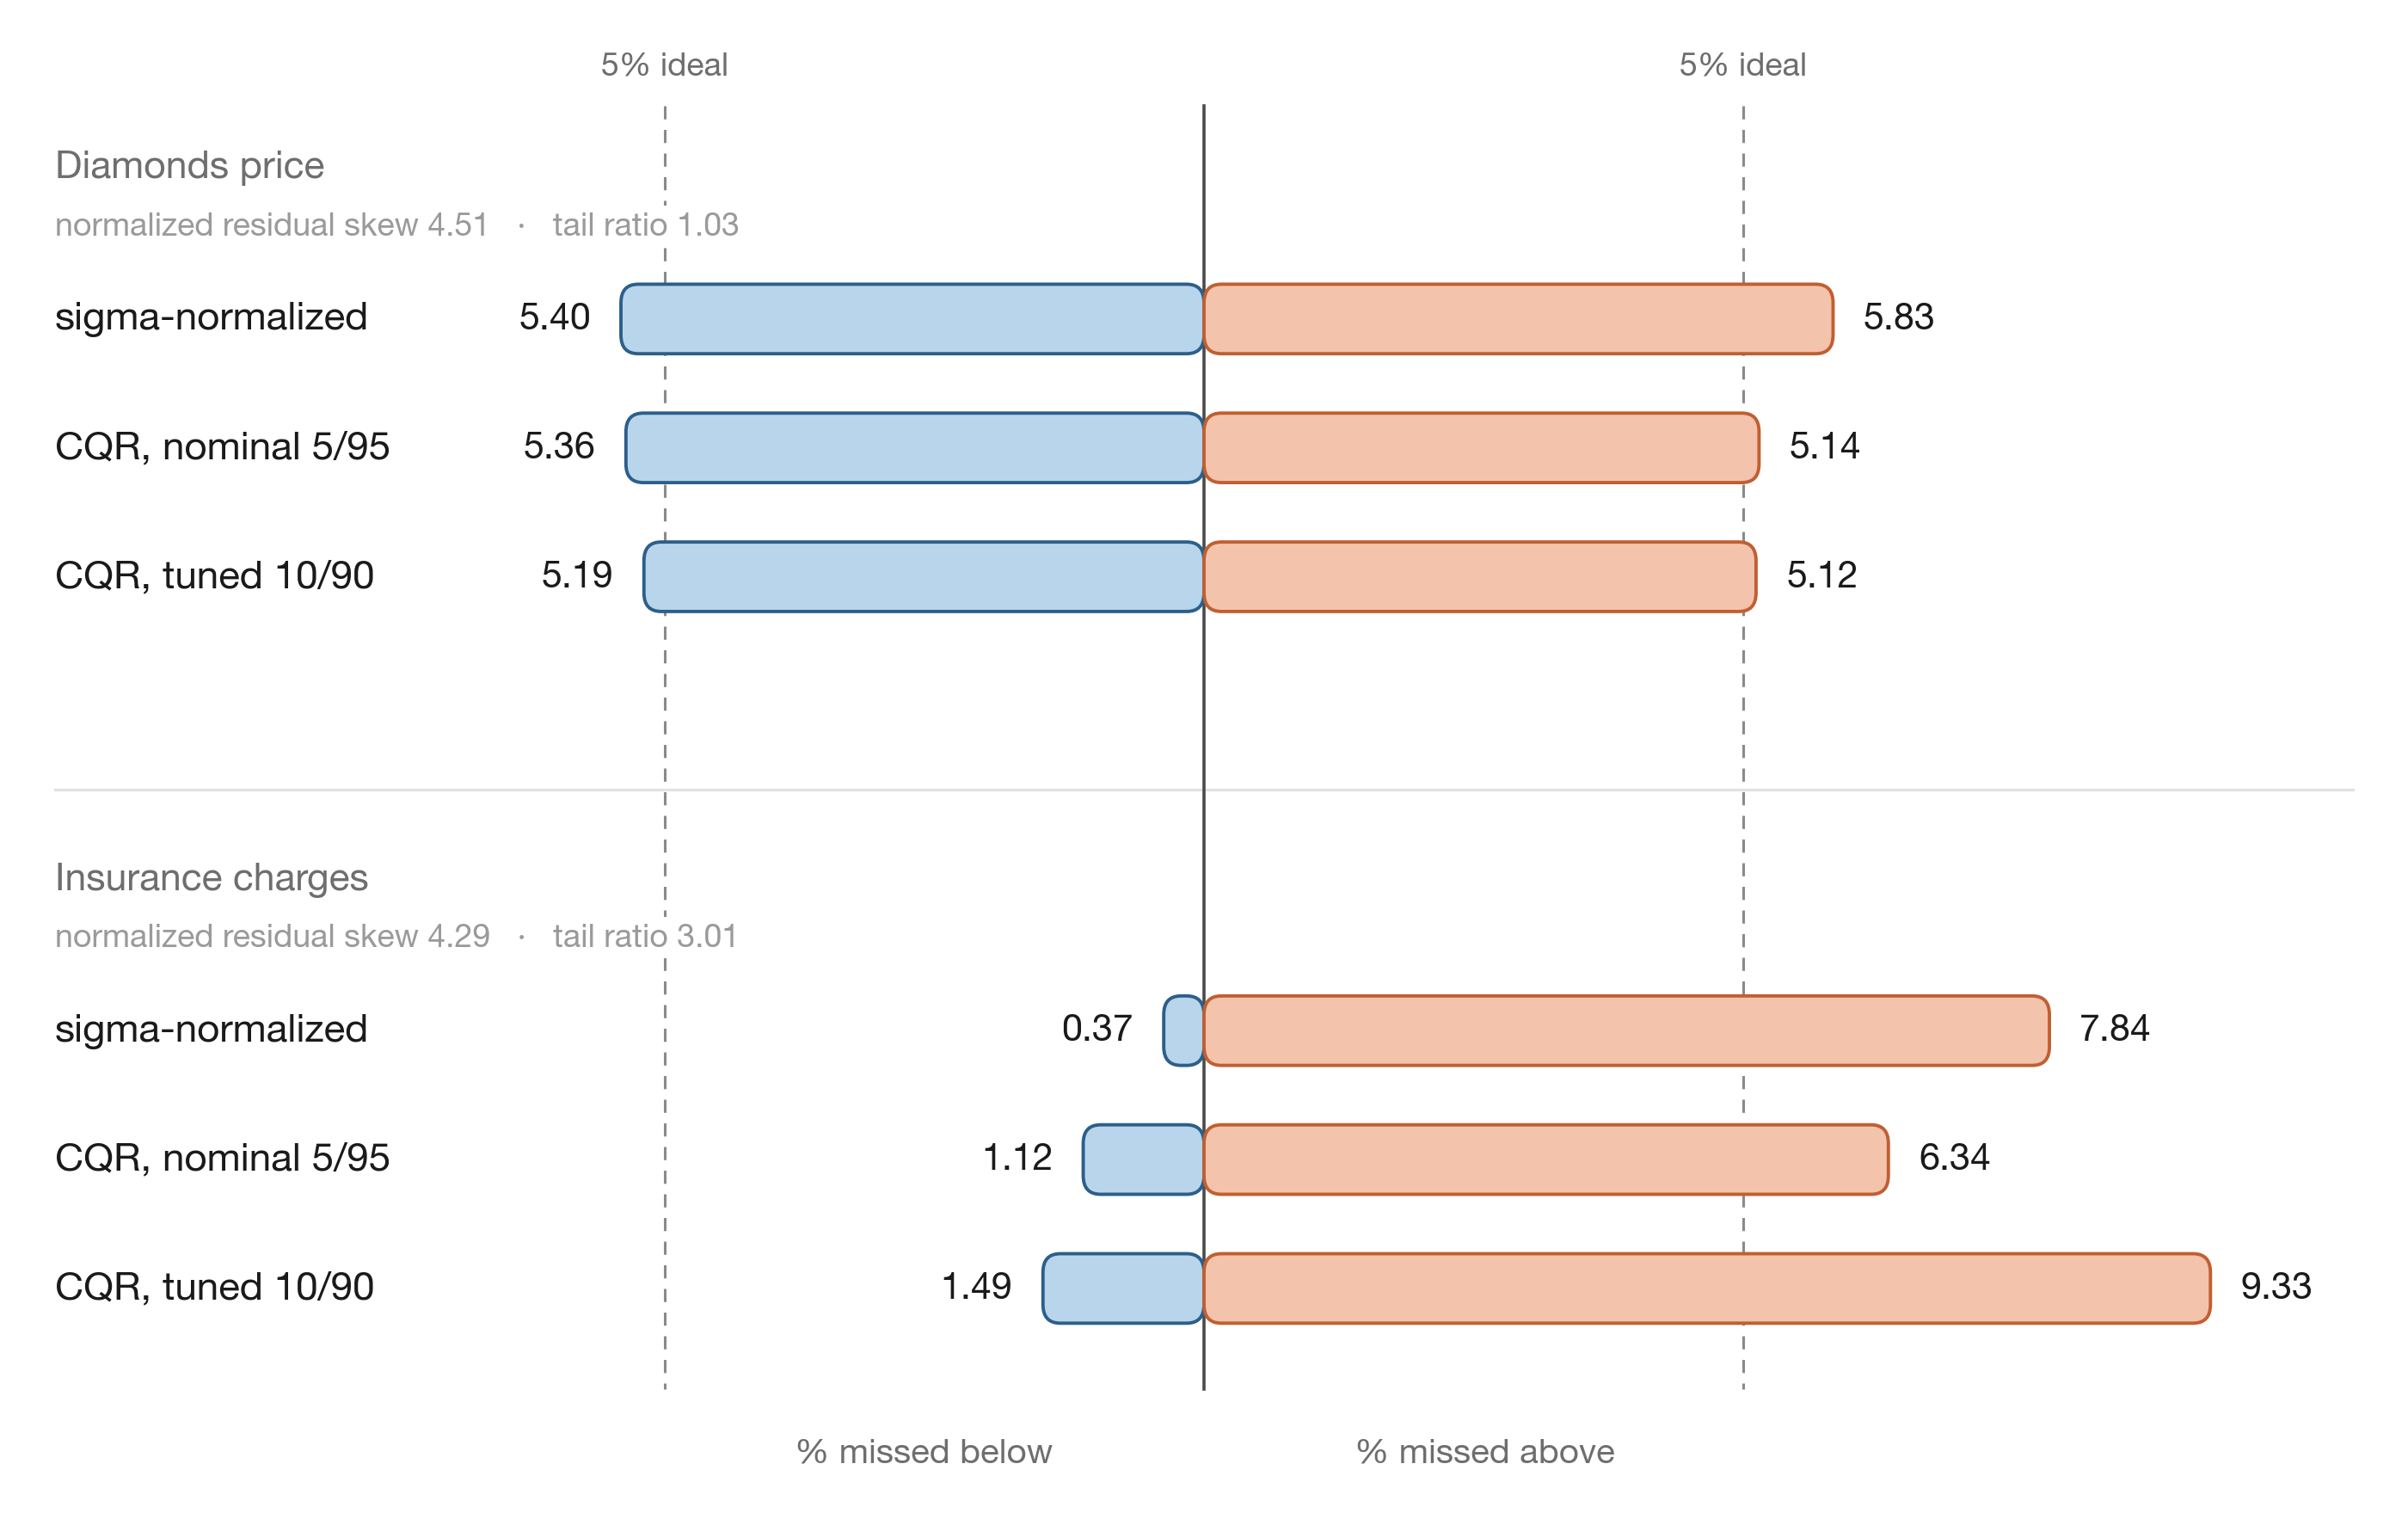

In [14]:
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch
from matplotlib.lines import Line2D

plt.rcParams["font.family"] = "sans-serif"
plt.rcParams["font.sans-serif"] = ["Helvetica Neue", "Helvetica", "Arial", "DejaVu Sans"]

BLUE_F, BLUE_E = "#B9D5EC", "#2C5F8A"
CORAL_F, CORAL_E = "#F4C3AC", "#C05F32"
INK, GREY, GREY2 = "#1a1a1a", "#6e6e6e", "#9a9a9a"

LABELS = {"sigma-normalized": "sigma-normalized",
          "CQR 5/95": "CQR, nominal 5/95",
          "CQR 10/90": "CQR, tuned 10/90"}

panels = []
for ds in ["Diamonds price", "Insurance charges"]:
    sub = results[results["dataset"] == ds].set_index("method")
    stats = (f"normalized residual skew {diags[ds]['moment_skew']:.2f}"
             f"   ·   tail ratio {diags[ds]['tail_ratio']:.2f}")
    panels.append((ds, stats, [(LABELS[m], sub.loc[m, "missed_below"], sub.loc[m, "missed_above"])
                               for m in LABELS]))

XMIN, XMAX, BH, R = -11.0, 11.0, 0.62, 0.16
fig_w, fig_h = 13.8, 8.6
fig = plt.figure(figsize=(fig_w, fig_h), dpi=200)
ax = fig.add_axes([0, 0, 1, 1])

rows_, marks, y = [], [], 0.85
for pi, (title, stats, entries) in enumerate(panels):
    if pi:
        y += 0.75; marks.append(("divider", y, None, None)); y += 0.80
    marks.append(("title", y, title, stats)); y += 1.35
    for name, lo, hi in entries:
        rows_.append((y, name, lo, hi)); y += 1.15
YMAX = y + 0.70

ax.set_xlim(XMIN, XMAX); ax.set_ylim(YMAX, -0.50); ax.axis("off")
mut_aspect = ((XMAX - XMIN) / fig_w) / ((YMAX + 0.50) / fig_h)

for xr in (-5, 5):
    ax.add_line(Line2D([xr, xr], [0.30, YMAX - 0.95], color="#8a8a8a", lw=1.1, ls=(0, (5, 4)), zorder=1))
    ax.text(xr, 0.07, "5% ideal", ha="center", va="bottom", fontsize=13.5, color=GREY)
ax.add_line(Line2D([0, 0], [0.30, YMAX - 0.95], color="#4a4a4a", lw=1.3, zorder=1))

for kind, yy, txt, stats in marks:
    if kind == "divider":
        ax.add_line(Line2D([XMIN + 0.35, XMAX - 0.35], [yy, yy], color="#e2e2e2", lw=1.2, zorder=0))
    else:
        ax.text(XMIN + 0.35, yy, txt, ha="left", va="center", fontsize=16, color=GREY, zorder=4,
                bbox=dict(facecolor="white", edgecolor="none", pad=2.5))
        ax.text(XMIN + 0.35, yy + 0.52, stats, ha="left", va="center", fontsize=13.5, color=GREY2,
                zorder=4, bbox=dict(facecolor="white", edgecolor="none", pad=2.5))

def bar(x0, x1, yc, fc, ec):
    ax.add_patch(FancyBboxPatch((min(x0, x1), yc - BH / 2), abs(x1 - x0), BH,
                                boxstyle=f"round,pad=0,rounding_size={R}", mutation_aspect=mut_aspect,
                                facecolor=fc, edgecolor=ec, lw=1.4, zorder=3))

for yc, name, lo, hi in rows_:
    ax.text(XMIN + 0.35, yc, name, ha="left", va="center", fontsize=16.5, color=INK)
    bar(-lo, 0, yc, BLUE_F, BLUE_E)
    bar(0, hi, yc, CORAL_F, CORAL_E)
    ax.text(-lo - 0.28, yc, f"{lo:.2f}", ha="right", va="center", fontsize=15.5, color=INK)
    ax.text(hi + 0.28, yc, f"{hi:.2f}", ha="left", va="center", fontsize=15.5, color=INK)

ax.text(-2.6, YMAX - 0.38, "% missed below", ha="center", va="center", fontsize=14.5, color=GREY)
ax.text(2.6, YMAX - 0.38, "% missed above", ha="center", va="center", fontsize=14.5, color=GREY)

fig.savefig("coverage_split.png", facecolor="white")
plt.show()

## Takeaway

The sigma from `RMSEWithUncertainty` is a fitted point estimate. Conformal calibration turns it into
an interval that carries a coverage guarantee.

Whether the symmetry of `mu +- Q sigma` costs you is a separate question, and the number that
answers it is a quantile, not a moment. A skewed target does not imply a skewed problem, and a high
normalized-residual skewness does not imply a lopsided interval.

With CQR the nominal quantile level is part of the method. Leave it at the target level and you pay
in width; tune it and you can pay in miss balance.